# PART 5. EDA (탐색적 데이터 분석)

## 수업 목표
- 그래프와 집계로 매출 추이, 리뷰, 인기 카테고리 패턴을 확인합니다.
- EDA는 "정답을 내는 과정"이 아니라 "데이터를 이해하는 과정"입니다.

## 수업 진행 포인트
| 구분 | 설명 |
|---|---|
| 데이터 관점 | 숫자보다 그래프로 전체 흐름을 먼저 봅니다. |
| 코드 관점 | groupby, value_counts, plot 사용법을 익힙니다. |
| AI 관점 | EDA 없이 AI를 바로 적용하면 잘못된 모델이 만들어집니다. |
| 강사 메모 | 그래프가 갑자기 떨어지는 이유(데이터 수집 종료)를 꼭 설명하세요. |

---

In [1]:
# 셀 1. Google Drive 연결

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 셀 2. 라이브러리 불러오기

import os
import pandas as pd
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/Olist/data"
print("경로 설정 완료!")

경로 설정 완료!


In [3]:
# 셀 3. 통합 데이터 불러오기
# PART 4에서 저장한 olist_master_data.csv를 사용합니다.

df = pd.read_csv(f"{base_path}/olist_master_data.csv")
print("데이터 크기:", df.shape)
df.head()

데이터 크기: (119143, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,14840.0,guariba,SP


In [4]:
# 셀 4. 기본 정보 확인
# info(): 컬럼명, 데이터 타입, 결측치 수를 한눈에 확인

df.info()
# ▶ Non-Null Count가 전체 행보다 적으면 결측치가 있다는 의미입니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [5]:
# 셀 5. 날짜 컬럼 변환
# "2017-10-02 10:56:33" 같은 문자열을 진짜 날짜 타입으로 변환합니다.
# 날짜 타입이 되어야 연도/월/요일 추출이 가능합니다.

df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"  # 변환 실패 시 NaT(빈 날짜)로 처리
)

df["year"]      = df["order_purchase_timestamp"].dt.year
df["month"]     = df["order_purchase_timestamp"].dt.month
df["dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
# ▶ dayofweek: 0=월요일, 1=화요일, ..., 6=일요일

df[["order_purchase_timestamp","year","month","dayofweek"]].head(3)

,order_purchase_timestamp,year,month,dayofweek
0,2017-10-02 10:56:33,2017,10,0
1,2017-10-02 10:56:33,2017,10,0
2,2017-10-02 10:56:33,2017,10,0


order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64


/tmp/ipykernel_1319/2498273495.py:12: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2498273495.py:12: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2498273495.py:12: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2498273495.py:12: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2498273495.py:12: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2498273495.py:12: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2498273495.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight

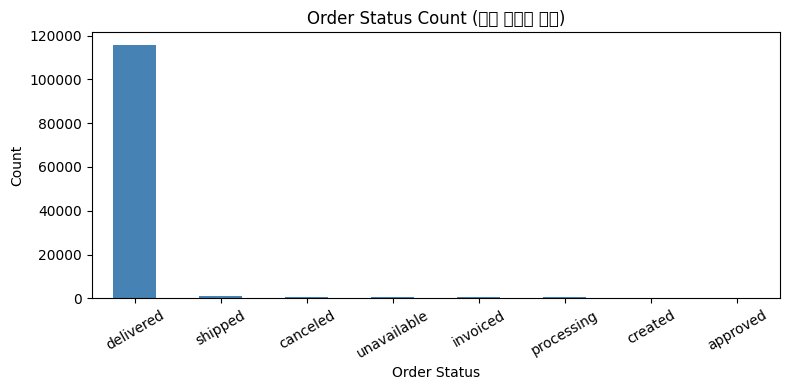

In [6]:
# 셀 6. 주문 상태 분포 확인
# delivered(배송완료)가 가장 많으면 정상입니다.

status_count = df["order_status"].value_counts()
print(status_count)

status_count.plot(kind="bar", figsize=(8, 4), color="steelblue")
plt.title("Order Status Count (주문 상태별 건수)")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("eda_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

| 주문 상태 | 의미 | 건수 |
|---|---|---|
| delivered | 배송 완료 | 115,723 |
| shipped | 배송 중 | 1,256 |
| canceled | 취소 | 750 |
| unavailable | 상품 없음 | 652 |

> delivered가 압도적으로 많다 → 대부분 주문이 정상 배송되었습니다.

In [8]:
# 셀 7. 월별 총 매출 분석
# dt.to_period("M"): 날짜를 "2017-10" 형태의 연-월로 변환
# groupby로 같은 월끼리 묶고 payment_value를 합산합니다.

monthly_sales = df.groupby(
    df["order_purchase_timestamp"].dt.to_period("M")
)["payment_value"].sum()

print(monthly_sales)

order_purchase_timestamp
2016-09        388.47
2016-10      76559.05
2016-12         19.62
2017-01     190806.27
2017-02     351848.13
2017-03     547769.84
2017-04     512126.52
2017-05     737425.31
2017-06     613777.41
2017-07     749242.84
2017-08     884168.36
2017-09    1030141.97
2017-10    1046083.41
2017-11    1610581.21
2017-12    1060949.63
2018-01    1425461.40
2018-02    1327338.97
2018-03    1486669.64
2018-04    1500373.12
2018-05    1512010.75
2018-06    1299683.17
2018-07    1362267.08
2018-08    1248942.63
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64


/tmp/ipykernel_1319/3642248730.py:7: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/3642248730.py:7: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/3642248730.py:7: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/3642248730.py:7: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/3642248730.py:7: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/3642248730.py:8: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.savefig("eda_monthly.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_1319/3642248730.py:8: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missi

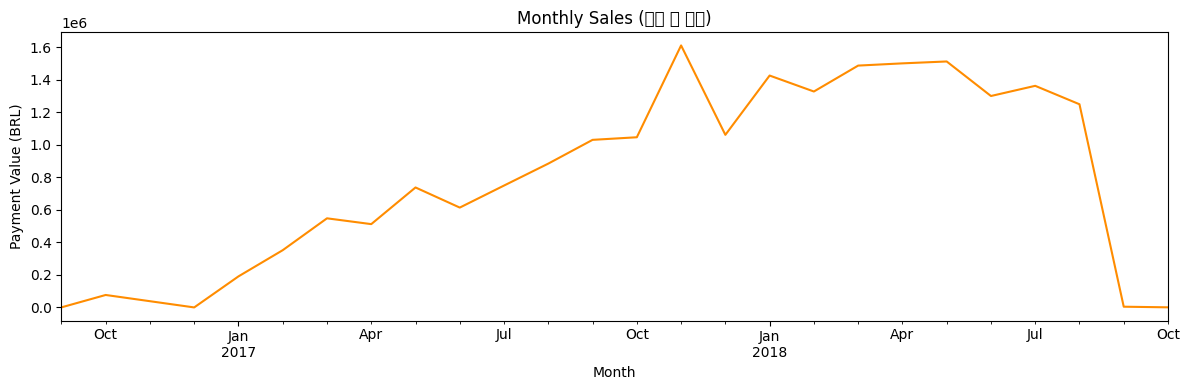

In [9]:
# 셀 8. 월별 총 매출 시각화

monthly_sales.plot(figsize=(12, 4), color="darkorange")
plt.title("Monthly Sales (월별 총 매출)")
plt.xlabel("Month")
plt.ylabel("Payment Value (BRL)")
plt.tight_layout()
plt.savefig("eda_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

## 그래프 해석

```
2016년 말 ~ 2017년 초  → 매출 성장 시작
2017년 하반기 ~ 2018년 → 본격적인 성장
마지막 구간 급락       → 데이터 수집 종료 영향
```

> **주의:** 마지막 구간이 급락한다고 실제 매출이 감소한 것이 아닙니다.
> 데이터 수집이 그 시점에 끊겼을 가능성이 높습니다.
> 아래 셀에서 주문 건수도 함께 확인하면 원인을 알 수 있습니다.

In [10]:
# 셀 9. 월별 주문 건수 확인 (매출 급락 원인 분석)
# 주문 건수도 같이 줄어들면 → 데이터 수집 종료가 원인

monthly_orders = df.groupby(
    df["order_purchase_timestamp"].dt.to_period("M")
)["order_id"].count()

print(monthly_orders)
# ▶ 마지막 달 주문 건수도 급락이면 데이터 부족이 원인입니다.

order_purchase_timestamp
2016-09       7
2016-10     401
2016-12       1
2017-01    1035
2017-02    2123
2017-03    3243
2017-04    2878
2017-05    4485
2017-06    3853
2017-07    4949
2017-08    5278
2017-09    5186
2017-10    5683
2017-11    9191
2017-12    6645
2018-01    8655
2018-02    8057
2018-03    8615
2018-04    8277
2018-05    8258
2018-06    7403
2018-07    7376
2018-08    7524
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64


product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: count, dtype: int64


/tmp/ipykernel_1319/2735497641.py:11: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2735497641.py:11: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2735497641.py:11: UserWarning: Glyph 52852 (\N{HANGUL SYLLABLE KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2735497641.py:11: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2735497641.py:11: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2735497641.py:11: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1319/2735497641.py:12: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.savefig("eda_m

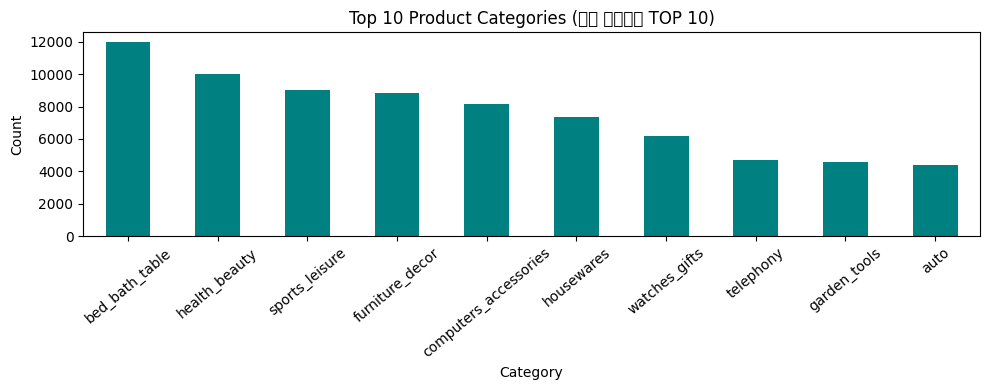

In [11]:
# 셀 10. 인기 상품 카테고리 TOP 10

top_categories = df["product_category_name_english"].value_counts().head(10)
print(top_categories)

top_categories.plot(kind="bar", figsize=(10, 4), color="teal")
plt.title("Top 10 Product Categories (인기 카테고리 TOP 10)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=40)
plt.tight_layout()
plt.savefig("eda_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64


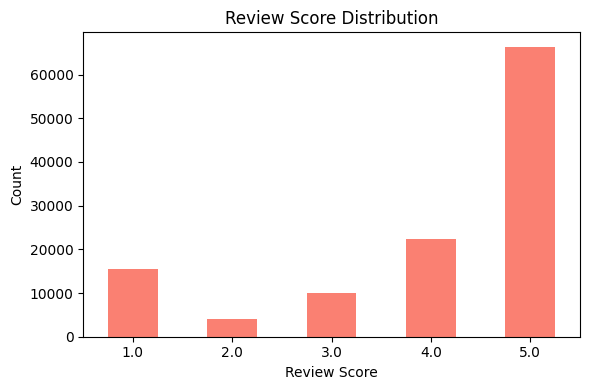

In [12]:
# 셀 11. 리뷰 점수 분포 확인
# 5점이 가장 많으면 고객 만족도가 높다는 의미입니다.

review_dist = df["review_score"].value_counts().sort_index()
print(review_dist)

review_dist.plot(kind="bar", figsize=(6, 4), color="salmon")
plt.title("Review Score Distribution") # 리뷰 점수 분포
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("eda_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# 셀 12. 행 수 vs 주문 수 차이 이해

print(f"전체 행 수:   {len(df):,}")
print(f"고유 주문 수: {df['order_id'].nunique():,}")
print()
print("행 수 > 주문 수인 이유:")
print("  주문 1건에 상품이 여러 개이면 행이 여러 줄 생성됩니다.")

전체 행 수:   119,143
고유 주문 수: 99,441

행 수 > 주문 수인 이유:
  주문 1건에 상품이 여러 개이면 행이 여러 줄 생성됩니다.


---

## 마무리 정리

| 확인할 내용 | 설명 |
|---|---|
| 이 파트의 핵심 | 그래프와 집계로 데이터의 패턴을 파악합니다. |
| 주의사항 | 그래프 급락 = 실제 매출 하락이 아닐 수 있습니다. 원인을 항상 확인하세요. |
| 다음 단계 | PART 6에서 추천 시스템을 구현합니다. |